# <center>Lecture 1: Random utility, welfare, and demand inversion</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 1** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering sections 1.1 (setting), 1.2 (demand map and welfare function), 1.3 (demand inversion and entropy of choice), 1.4 (sampling), 1.5 (asymptotic theory) and 1.6 (comparative statics). It runs the book's code listings `1-01` and `1-02` and extends them. Slide deck: folders `ch1/ch1.1`–`ch1/ch1.6`.

### Learning objectives

* The welfare function $G$, the market share map $\pi$, and the Daly–Zachary–Williams theorem $\pi = \nabla G$.
* Demand inversion as a concave maximization problem, and the generalized entropy of choice $G^\ast$ as its value.
* The inversion theorem: $-G^\ast$ is the value of an optimal transport problem, and the systematic utilities are its dual variables.
* The empirical counterparts $\hat G$, $\hat \pi$, $\hat G^\ast$, and the linear program that computes demand inversion from simulated shocks.
* Asymptotics of the inverted utilities, and the substitution structure of $D\pi$.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 1** — this notebook follows its sections and numbering; see also its "References and Notes".
* Daly and Zachary (1979); Williams (1977). The theorem now known as Daly–Zachary–Williams.
* McFadden (1981). "Econometric Models of Probabilistic Choice", in Manski and McFadden (eds.), *Structural Analysis of Discrete Data with Econometric Applications*, MIT Press.
* Galichon and Salanié (2022). "Cupid's Invisible Hand: Social Surplus and Identification in Matching Models". *Review of Economic Studies* (first version 2011). Source of the generalized entropy of choice.
* Chiong, Galichon and Shum (2016). "Duality in Dynamic Discrete Choice Models". *Quantitative Economics* 7, 83–115. Source of the linear-programming inversion.
* Berry (1994). "Estimating Discrete-Choice Models of Product Differentiation". *RAND Journal of Economics*.
* Greene and Hensher (1997). *Multinomial Logit and Discrete Choice Models*. Source of the travel-mode data used throughout the series.
* Companion m+e+c notebooks: `lp01_lp-intro` and `lp02_simplex` for the linear programming used here; `ot01_optimal-assignment` for the discrete optimal transport problem that reappears in section 4.

## Motivation: the theorist's problem and the econometrician's

A consumer picks one option out of finitely many. The analyst sees the *shares* — what fraction of travellers flew, took the train, took the bus, drove — and wants the *utilities* that rationalize them. That is the inverse of the problem a theorist solves.

Chapter 1 shows that these two problems are one convex-analytic object seen from two sides. The welfare function

$$G(U) = \mathbb{E}_{\mathcal{P}}\Big[\max_{y\in[Y]}\{U_y + \varepsilon_y,\ \varepsilon_0\}\Big]$$

is convex; its gradient is the market share map, $\pi = \nabla G$; its Legendre–Fenchel transform $G^\ast$ is the *generalized entropy of choice*; and its gradient inverts demand, $\pi^{-1} = \nabla G^\ast$. Every later notebook in this series is a specialization of this pair: chapter 2 puts a distribution on $\varepsilon$ that makes $G$ a log-sum-exp; chapter 3 parametrizes $U$ and estimates it; chapter 4 adds unobserved product characteristics; chapter 6 makes $U$ a continuation value; chapter 7 adds a capacity constraint whose multiplier prices a queue.

**The dual object.** Section 4 below identifies it precisely. The primal variable is a *coupling* $\lambda_{iy}$ — a matching between consumers (their shocks) and options, an occupation measure over $[I]\times[0{:}Y]$. The dual variables are the indirect utilities $u_i$ (one potential per consumer) and the systematic utilities $U_y$ (one price per option). Complementary slackness says a consumer is matched to an option only when their utility constraint binds — that is, only when the option is their argmax. **Demand inversion is an optimal transport problem, and the systematic utilities are its prices.** Everything else in the notebook is a check on that statement.

What this notebook does: build $G$, $\pi$, $G^\ast$ from scratch; verify $\pi = \nabla G$ numerically; compute $G^\ast$ three independent ways (closed form, conjugate maximization, and as the value of an optimal transport LP); check that the LP's dual variables converge to the true utilities; quantify how fast; and read the substitution structure off the Jacobian.

### Notation

We follow the book. Options are $y \in [0{:}Y] = \{0\}\cup[Y]$, with $y=0$ the *default option* and the normalization $U_0 = 0$. Consumer $i$ associates utility $U_y + \varepsilon_{iy}$ to option $y$; $U$ is the vector of **systematic utilities**, $\varepsilon_i \sim \mathcal{P}$ the vector of **utility shocks**. The **market share map** is $\pi(U)$ (bold in the book, plain here), the **welfare function** is $G$, the **entropy of choice** is $G^\ast$.

Two deviations from the usual m+e+c conventions, both inherited from the book and kept for the whole `dc` series:

* $u$ denotes the consumer's *indirect utility* $u(\varepsilon) = \max_y\{U_y+\varepsilon_y\}$ — the natural meaning here, and the LP dual variable in section 4. It is never a control.
* $\sigma$ is **not** the demand map (the book writes $\pi$); it is left free for the scale, or *temperature*, of the shocks, which is how chapter 3 uses it.

Arrays carry their axes: `U_y`, `epsilon_i_y`, `pi_y`, `muhat_i_y`; dimensions are `I`, `Y`; a concatenated suffix is the row-major flattening, `epsilon_iy = epsilon_i_y.reshape(-1)`. Note that `Y` counts the *alternatives* $[Y]$, so arrays over all options $[0{:}Y]$ have length `Y + 1`.

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.optimize import linprog, minimize
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)          # lecture number
FAST_MODE = True                        # classroom setting; see the last cell

np.set_printoptions(precision=4, suppress=True)
print('numpy', np.__version__)

numpy 2.5.2


## 1. The setting, and our running data

*(Book, section 1.1.)*

Throughout the `dc` series the running dataset is Greene and Hensher's (1997) travel-mode survey: 210 travellers choosing between Sydney, Canberra and Melbourne among four modes — air, train, bus, car — with the time and money costs of each. There are $840 = 4\times 210$ rows.

We take **car as the default option** $y=0$: it is the mode available to everyone without a booking, and it is the natural "do it yourself" outside option. The alternatives are then $[Y] = \{1,2,3\} = \{$air, train, bus$\}$ and $Y=3$.

In [2]:
from pathlib import Path


def read_mec_csv(relative_path):
    """Load a dataset locally when available, otherwise use the public mirror."""
    for parent in (Path.cwd(), *Path.cwd().parents):
        local = parent / 'mec_datasets' / relative_path
        if local.is_file():
            return pd.read_csv(local)
    url = ('https://raw.githubusercontent.com/math-econ-code/'
           'mec_datasets/main/' + relative_path)
    try:
        return pd.read_csv(url)
    except Exception as exc:
        raise RuntimeError(
            f'could not load {relative_path}; no local mec_datasets copy was found '
            f'and the download failed: {url}'
        ) from exc


travelmode = read_mec_csv('demand_travelmode/travelmodedata.csv')

# options ordered so that y = 0 is the default (car)
options = ['car', 'air', 'train', 'bus']
Y = len(options) - 1                       # number of alternatives Y
I = travelmode['individual'].nunique()     # number of consumers I

travelmode['choice'] = (travelmode['choice'] == 'yes').astype(int)
wide = (travelmode.pivot(index='individual', columns='mode', values='choice')
                  .reindex(columns=options))
muhat_i_y = wide.to_numpy()                  # axes (i, y), y in [0:Y]

assert muhat_i_y.shape == (I, Y + 1)
assert (muhat_i_y.sum(axis=1) == 1).all(), 'each traveller makes exactly one choice'

pihat_y = muhat_i_y.mean(axis=0)             # observed market shares over [0:Y]
print('I =', I, ' Y =', Y, ' options =', options)
print('observed shares pihat_y =', pihat_y, ' (sum =', pihat_y.sum(), ')')

I = 210  Y = 3  options = ['car', 'air', 'train', 'bus']
observed shares pihat_y = [0.281  0.2762 0.3    0.1429]  (sum = 1.0 )


Train is the most-chosen mode at 30%, with car and air close behind at about 28% each; bus trails at 14%. The four shares sum to one, as they must. These are the $\hat\pi_y$ of section 1.4, and we will invert them in section 6.

## 2. The welfare function and the demand map

*(Book, section 1.2. Runs listing `1-01`.)*

Given a draw $\varepsilon$, the consumer's indirect utility is
$$u(\varepsilon) = \max_{y\in[Y]}\{U_y + \varepsilon_y,\ \varepsilon_0\},$$
and the **welfare function** is its expectation,
$$\boxed{\;G(U) = \mathbb{E}_{\mathcal{P}}\Big[\max_{y\in[Y]}\{U_y+\varepsilon_y,\ \varepsilon_0\}\Big].\;}$$

Under the **continuity assumption** (assumption 1.1: $\mathcal{P}$ has a density on $\mathbb{R}^{Y+1}$) ties have probability zero and the **market share map** is well defined,
$$\pi_y(U) = \mathcal{P}\big(U_y+\varepsilon_y \ge U_z+\varepsilon_z,\ \forall z \in [0{:}Y]\big).$$

$G$ is an expectation of maxima of affine functions of $U$, hence **convex**; and $\partial G/\partial U_y$ is nonincreasing in $U_z$ for $z\neq y$, hence **submodular** (proposition 1.1). The link between the two objects is the central result of the section:

> **Theorem (Daly–Zachary–Williams; book theorem 1.1).** Under assumption 1.1, $G$ is $C^1$ and
> $$\pi(U) = \nabla G(U).$$

The intuition is a one-line envelope argument: raising $U_y$ by $\delta$ raises the indirect utility of exactly the consumers who were choosing $y$, and the mass who switch is $O(\delta^2)$.

The empirical counterparts of section 1.4 replace $\mathcal{P}$ by the empirical distribution $\mathcal{P}_I$ of $I$ draws:
$$\hat G(U) = \frac1I\sum_{i}\max_{y}\{U_y+\varepsilon_{iy},\varepsilon_{i0}\},\qquad
\hat\pi_y(U) = \frac1I\sum_i \mathbf{1}\{U_y+\varepsilon_{iy}\ge U_z+\varepsilon_{iz}\ \forall z\}.$$
This is the **accept–reject simulator**, equation (1.11) of the book, and it is what listing `1-01` computes.

In [3]:
def welfare_and_shares(U_y, epsilon_i_y):
    '''Empirical welfare Ghat(U) and market shares pihat_y(U) --- book listing 1-01.

    U_y          : (Y+1,) systematic utilities over [0:Y], with U_y[0] = 0
    epsilon_i_y  : (I, Y+1) utility shocks, one row per consumer
    returns      : Ghat (float), pihat_y (Y+1,) summing to one
    '''
    u_i_y = U_y[None, :] + epsilon_i_y          # utility of every option for every consumer
    u_i = u_i_y.max(axis=1)                     # indirect utility
    Ghat = u_i.mean()
    mu_i_y = (u_i_y == u_i[:, None])            # argmax indicator; ties a.s. absent
    pihat_y = mu_i_y.sum(axis=0) / epsilon_i_y.shape[0]
    return Ghat, pihat_y


# the book's listing 1-01, verbatim in intent, in house notation
U_y_demo = np.array([0.0, 0.9, 0.7, 0.3])
eps_demo = rng.normal(size=(100, Y + 1))
Ghat_demo, pihat_demo = welfare_and_shares(U_y_demo, eps_demo)
print('listing 1-01 with I = 100 :  G(U) =', round(Ghat_demo, 4), '  pi_y =', pihat_demo)

listing 1-01 with I = 100 :  G(U) = 1.4585   pi_y = [0.1  0.44 0.3  0.16]


With $I=100$ draws the shares are accurate to about $\pm 0.05$ — the crude-simulation precision discussed at the end of book section 1.5, where the standard deviation of $\hat\pi_y$ is $\sqrt{\pi_y(1-\pi_y)/I}$. We raise $I$ before doing anything quantitative.

### Verification: Daly–Zachary–Williams, numerically

$\hat G$ is piecewise linear in $U$ with kinks where a consumer switches. Using **common random numbers** — the same $\varepsilon$ draws at $U+he_y$ and $U-he_y$ — a central difference of $\hat G$ is exactly $\hat\pi_y$ unless some consumer switches inside the window, an event of probability $O(h)$. So the check should pass to several digits.

In [4]:
I_mc = 200_000 if not FAST_MODE else 100_000
eps_mc = rng.normal(size=(I_mc, Y + 1))        # common random numbers, fixed once
U_y0 = np.array([0.0, 0.9, 0.7, 0.3])

G0, pi_mc = welfare_and_shares(U_y0, eps_mc)

h = 1e-3
grad_fd = np.zeros(Y + 1)
for y in range(1, Y + 1):                        # U_0 is held at 0 by normalization
    e_y = np.zeros(Y + 1); e_y[y] = 1.0
    Gp, _ = welfare_and_shares(U_y0 + h * e_y, eps_mc)
    Gm, _ = welfare_and_shares(U_y0 - h * e_y, eps_mc)
    grad_fd[y] = (Gp - Gm) / (2 * h)

err = np.abs(grad_fd[1:] - pi_mc[1:]).max()
print('finite-difference dGhat/dU_y :', grad_fd[1:])
print('simulated market shares      :', pi_mc[1:])
print(f'DZW check: max |dG/dU_y - pi_y| = {err:.2e}   (tolerance 1e-3)')
assert err < 1e-3

finite-difference dGhat/dU_y : [0.4001 0.3104 0.1779]
simulated market shares      : [0.4001 0.3104 0.1779]
DZW check: max |dG/dU_y - pi_y| = 2.32e-05   (tolerance 1e-3)


The gradient of the welfare function *is* the vector of market shares, to better than $10^{-3}$ with $10^5$ common draws and a step $h=10^{-3}$. Note what made the check sharp: common random numbers. Redrawing the shocks at $U\pm he_y$ would have swamped the signal in Monte Carlo noise of order $I^{-1/2}/h \approx 3$.

### The logit model, in closed form

*(Book, example 1.2. Developed in full in lecture 2.)*

If the $\varepsilon_y$ are i.i.d. centered Gumbel with scale 1, then
$$G(U) = \log\Big(1+\sum_{y\in[Y]}e^{U_y}\Big),\qquad
\pi_y(U) = \frac{e^{U_y}}{1+\sum_{z\in[Y]}e^{U_z}},$$
and $D^2G(U) = \Delta_\pi - \pi\pi^\top$, a symmetric positive definite matrix with negative off-diagonal entries — a *Stieltjes matrix*, consistent with $G$ being convex and submodular. We will use the logit as the case where every object of this notebook has a closed form to check against.

In [5]:
def G_logit(U_y):
    '''Welfare function of the logit model; U_y over [0:Y] with U_y[0] = 0.'''
    return np.logaddexp.reduce(U_y)                      # = log sum exp, stable


def pi_logit(U_y):
    '''Market share map of the logit model; returns shares over [0:Y].'''
    return np.exp(U_y - np.logaddexp.reduce(U_y))


def D2G_logit(pi_y):
    '''Hessian of G at U with pi = pi(U); over the alternatives [Y] only.'''
    p = pi_y[1:]
    return np.diag(p) - np.outer(p, p)


# Monte Carlo check of the closed forms, with Gumbel draws
gumbel_i_y = rng.gumbel(loc=-np.euler_gamma, scale=1.0, size=(I_mc, Y + 1))
G_sim, pi_sim = welfare_and_shares(U_y0, gumbel_i_y)

print('G  closed form / simulated :', round(G_logit(U_y0), 4), '/', round(G_sim, 4))
print('pi closed form :', pi_logit(U_y0))
print('pi simulated   :', pi_sim)
se = np.sqrt(pi_logit(U_y0) * (1 - pi_logit(U_y0)) / I_mc)
print('pi discrepancy in simulation standard errors :',
      np.abs(pi_sim - pi_logit(U_y0)) / se)

G  closed form / simulated : 1.9203 / 1.9219
pi closed form : [0.1466 0.3605 0.2951 0.1978]
pi simulated   : [0.1468 0.3624 0.2938 0.197 ]
pi discrepancy in simulation standard errors : [0.2338 1.2608 0.9031 0.6932]


Every share sits within about one and a quarter simulation standard errors of its closed form, and $G$ agrees to better than $0.002$. The Gumbel is drawn *centered* — `loc = -euler_gamma` — because the book's convention is $\mathbb{E}[\varepsilon_y]=0$; the standard Gumbel would shift $G$ by $\gamma\approx 0.5772$ without changing any share. Getting this convention wrong is the single most common source of a mismatched intercept in logit code.

## 3. Demand inversion and the entropy of choice

*(Book, section 1.3.)*

The econometrician's problem is the inverse: given shares $\pi$ with $\pi_y>0$ and $\sum_{y\in[Y]}\pi_y<1$, find
$\pi^{-1}(\pi) = \{U : \pi(U)=\pi\}$.

Since $\pi(U)=\nabla G(U)$, the equation $\pi(U)=\pi$ is the first-order condition of a concave program:

> **Proposition (book 1.2).** Under assumption 1.1, $U\in\pi^{-1}(\pi)$ if and only if
> $$U \in \arg\max_{\tilde U\in\mathbb{R}^Y}\Big\{\pi^\top\tilde U - G(\tilde U)\Big\}.$$

Its **value** is the Legendre–Fenchel transform of $G$, which Galichon and Salanié named the **generalized entropy of choice**:
$$\boxed{\;G^\ast(\pi) = \max_{U\in\mathbb{R}^Y}\Big\{\textstyle\sum_{y\in[Y]}\pi_y U_y - G(U)\Big\}.\;}$$

By the envelope theorem $\pi^{-1} = \nabla G^\ast$ (book theorem 1.3). Existence and uniqueness split cleanly along the two assumptions (book theorem 1.2): **continuity** gives *at least* one solution, **full support** gives *at most* one. The binomial picture explains both — a jump in the c.d.f. of $\varepsilon_1$ kills existence, a flat kills uniqueness.

$G^\ast$ has an interpretation that will recur throughout the series. Writing $y^\star(\varepsilon)$ for the chosen option,
$$G^\ast(\pi) = -\,\mathbb{E}\big[\varepsilon_{y^\star(\varepsilon)}\big]:$$
**minus the expected amount of heterogeneity needed to rationalize the shares $\pi$.** In the logit case it is the Gibbs entropy,
$$G^\ast(\pi)=\sum_{y\in[0:Y]}\pi_y\log\pi_y,\qquad (\pi^{-1})_y(\pi)=\log\frac{\pi_y}{\pi_0},$$
the celebrated **log-odds formula**: the log odds of $y$ against the default identify the difference in systematic utilities.

In [6]:
def Gstar_logit(pi_y):
    '''Entropy of choice in the logit model; pi_y over [0:Y].'''
    return float(np.sum(pi_y * np.log(pi_y)))


def inverse_pi_logit(pi_y):
    '''Log-odds inversion: U_y = log(pi_y / pi_0), over [0:Y] with U_0 = 0.'''
    return np.log(pi_y) - np.log(pi_y[0])


def Gstar_by_maximization(pi_y, G):
    '''G*(pi) computed as the value of the concave program, for any welfare function G.

    Maximizes  sum_y pi_y U_y - G(U)  over U in R^Y (with U_0 = 0),
    and returns the value together with the maximizer, which is pi^{-1}(pi).
    '''
    def neg_obj(U_free):
        U_y = np.concatenate(([0.0], U_free))
        return -(np.dot(pi_y[1:], U_free) - G(U_y))

    res = minimize(neg_obj, x0=np.zeros(len(pi_y) - 1), method='BFGS',
                   options={'gtol': 1e-10})
    return -res.fun, np.concatenate(([0.0], res.x)), res


pi_target = pi_logit(U_y0)

Gstar_cf = Gstar_logit(pi_target)
U_cf = inverse_pi_logit(pi_target)
Gstar_num, U_num, res = Gstar_by_maximization(pi_target, G_logit)

print(f'G*  closed form   : {Gstar_cf: .8f}')
print(f'G*  maximization  : {Gstar_num: .8f}    gap = {abs(Gstar_cf-Gstar_num):.2e}')
print('U   log-odds      :', U_cf)
print('U   maximization  :', U_num)
print('U   true          :', U_y0)
print(f'inversion error   : {np.abs(U_num - U_y0).max():.2e}   (tolerance 1e-6)')
assert abs(Gstar_cf - Gstar_num) < 1e-8 and np.abs(U_num - U_y0).max() < 1e-6

G*  closed form   : -1.32995982
G*  maximization  : -1.32995982    gap = 8.88e-16
U   log-odds      : [0.  0.9 0.7 0.3]
U   maximization  : [0.  0.9 0.7 0.3]
U   true          : [0.  0.9 0.7 0.3]
inversion error   : 1.35e-07   (tolerance 1e-6)


Three objects agree: the closed-form entropy, the value of the concave program, and — recovered as the *maximizer* of that same program — the systematic utilities we started from. The round trip $U \to \pi(U) \to \pi^{-1}(\pi) = U$ closes to $10^{-6}$.

This is worth pausing on. We did not invert anything. We *maximized* a concave function, and the argmax was the inverse demand. That is the reformulation that makes chapter 4's BLP contraction, chapter 6's dynamic inversion, and chapter 7's rationed choice all instances of one computation.

## 4. Demand inversion is an optimal transport problem

*(Book, section 1.3, theorem 1.4, and section 1.4, theorem 1.5. Runs listing `1-02`.)*

This is the duality spine of the series, so we state it carefully.

> **Theorem (inversion theorem; book theorem 1.4).** Let $\mathcal{M}(\mathcal{P},\pi)$ be the set of joint distributions of pairs $(\varepsilon,\tilde y)$ with $\varepsilon\sim\mathcal{P}$ and $\tilde y\sim\pi$. Then $-G^\ast(\pi)$ is the value of the Monge–Kantorovich problem
> $$-G^\ast(\pi) = \max_{\lambda\in\mathcal{M}(\mathcal{P},\pi)} \mathbb{E}_\lambda[\varepsilon_{\tilde y}],$$
> whose dual is
> $$-G^\ast(\pi) = \min_{u,U}\ \int u(\varepsilon)\,d\mathcal{P}(\varepsilon) - \sum_{y\in[0:Y]}\pi_y U_y
> \quad\text{s.t.}\quad u(\varepsilon) - U_y \ge \varepsilon_y\ \ \forall \varepsilon, y,$$
> and under assumption 1.1, $U\in\pi^{-1}(\pi)$ if and only if $(u,U)$ solves the dual with $U_0=0$.

Read the economics off the dual. The constraint $u(\varepsilon) \ge U_y + \varepsilon_y$ says the consumer's realized utility dominates every option; at the optimum it binds at the chosen one. The multiplier $\lambda_{iy}$ on that constraint is the mass of consumers of type $\varepsilon_i$ assigned to option $y$. **The systematic utilities are the prices that clear a matching market between consumers' tastes and the alternatives**, and $-G^\ast$ is the value of that market. This is the same object as `ot01_optimal-assignment`, with consumers on one side and options on the other.

Replacing $\mathcal{P}$ by the empirical $\mathcal{P}_I$ turns this into a finite LP (book theorem 1.5):

$$\textbf{(primal)}\quad \max_{\lambda_{iy}\ge 0}\ \sum_{iy}\lambda_{iy}\varepsilon_{iy}
\quad\text{s.t.}\quad \sum_y \lambda_{iy}=\tfrac1I,\quad \sum_i\lambda_{iy}=\pi_y,$$

$$\textbf{(dual)}\quad \min_{u_i,U_y}\ \frac1I\sum_i u_i - \sum_{y}\pi_y U_y
\quad\text{s.t.}\quad u_i - U_y \ge \varepsilon_{iy},\quad U_0=0.$$

Vectorized with row-major flattening $\varepsilon_{iy}$ (book appendix on vectorization), the dual constraint is
$$(\mathbf{I}_I\otimes\mathbf{1}_{Y+1})\,u - (\mathbf{1}_I\otimes\mathbf{I}_{Y+1})\,U \ \ge\ \varepsilon.$$

Listing `1-02` solves this with Gurobi. We use **HiGHS through `scipy.optimize.linprog`** instead, so that the notebook runs on a bare Colab kernel with no licence; the formulation is identical, and the Kronecker assembly is the book's.

In [7]:
def inversion_lp(pi_y, epsilon_i_y):
    '''Demand inversion by linear programming --- book listing 1-02, in HiGHS.

    Solves the DUAL of the finite optimal transport problem:
        min_{u,U}  (1/I) sum_i u_i - sum_{y in [Y]} pi_y U_y
        s.t.       u_i - U_y >= epsilon_iy   for all i, y in [0:Y],   U_0 = 0.

    Returns U_y (over [0:Y], with U_y[0] = 0), u_i, and the LP value, which is -Ghat*(pi).
    '''
    I_, Yp1 = epsilon_i_y.shape
    Y_ = Yp1 - 1
    epsilon_iy = epsilon_i_y.reshape(-1)                      # vec_R, row-major

    # variables z = (u_1..u_I, U_1..U_Y);  U_0 is eliminated by the normalization
    Sigma_i = sp.kron(sp.eye(I_), np.ones((Yp1, 1)))      # picks u_i on row iy
    Sigma_y = sp.kron(np.ones((I_, 1)), sp.eye(Yp1)).tocsc()
    Sigma_y = Sigma_y[:, 1:]                                  # drop the U_0 column

    A_ub = sp.hstack([-Sigma_i, Sigma_y]).tocsr()             # -u_i + U_y <= -eps_iy
    b_ub = -epsilon_iy
    c = np.concatenate([np.ones(I_) / I_, -pi_y[1:]])

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(None, None), method='highs')
    if not res.success:
        raise RuntimeError(res.message)
    u_i = res.x[:I_]
    U_y = np.concatenate(([0.0], res.x[I_:]))
    lam_iy = -res.ineqlin.marginals                           # primal coupling
    return U_y, u_i, res.fun, lam_iy.reshape(I_, Yp1)


def inversion_lp_primal(pi_y, epsilon_i_y):
    '''The primal optimal transport problem, solved independently as a cross-check.'''
    I_, Yp1 = epsilon_i_y.shape
    A_i = sp.kron(sp.eye(I_), np.ones((1, Yp1)))          # sum_y lambda_iy = 1/I
    A_y = sp.kron(np.ones((1, I_)), sp.eye(Yp1))          # sum_i lambda_iy = pi_y
    A_eq = sp.vstack([A_i, A_y]).tocsr()
    b_eq = np.concatenate([np.ones(I_) / I_, pi_y])
    res = linprog(-epsilon_i_y.reshape(-1), A_eq=A_eq, b_eq=b_eq,
                  bounds=(0, None), method='highs')
    if not res.success:
        raise RuntimeError(res.message)
    return -res.fun, res.x.reshape(I_, Yp1)               # value = max sum lambda eps

In [8]:
# listing 1-02's example, with Gaussian shocks and the shares it uses
I_lp = 100
pi_lp = np.array([27, 19, 25, 29]) / I_lp
eps_lp = rng.normal(size=(I_lp, Y + 1))

U_lp, u_lp, dual_val, lam_lp = inversion_lp(pi_lp, eps_lp)
primal_val, lam_primal = inversion_lp_primal(pi_lp, eps_lp)

print('listing 1-02, I = 100, Gaussian shocks')
print('  U_y            =', U_lp)
print(f'  Ghat*(pi)      = {-dual_val: .8f}')
print(f'  dual value     = {dual_val: .8f}')
print(f'  primal value   = {primal_val: .8f}')
print(f'  duality gap    = {abs(dual_val - primal_val):.2e}   (tolerance 1e-9)')
assert abs(dual_val - primal_val) < 1e-9

listing 1-02, I = 100, Gaussian shocks
  U_y            = [ 0.     -0.0623 -0.1469  0.439 ]
  Ghat*(pi)      = -1.04311521
  dual value     =  1.04311521
  primal value   =  1.04311521
  duality gap    = 2.22e-16   (tolerance 1e-9)


**Verification 2: primal equals dual.** The two linear programs were assembled and solved independently — one over the coupling $\lambda_{iy}$, one over the potentials $(u_i,U_y)$ — and their values agree to $10^{-9}$. That is the strong duality of the optimal transport problem, and it is the check the charter asks for whenever a model is stated as a primal–dual pair.

**Verification 3: complementary slackness.** The economics of the dual is the statement that a consumer receives positive mass on an option only where their constraint binds — that is, only at their argmax. We check it directly.

In [9]:
slack_i_y = u_lp[:, None] - U_lp[None, :] - eps_lp          # >= 0 by feasibility
active = lam_lp > 1e-9

print(f'min slack over all (i,y)            : {slack_i_y.min():.2e}   (feasibility, >= 0)')
print(f'max slack where lambda_iy > 0       : {slack_i_y[active].max():.2e}   (complementarity, = 0)')
print(f'mass assigned to a non-argmax option: '
      f'{lam_lp[(slack_i_y > 1e-8) & active].sum():.2e}')

# and the coupling's marginals reproduce the data it was built from
print('row marginals equal 1/I  :', np.allclose(lam_lp.sum(axis=1), 1 / I_lp, atol=1e-9))
print('col marginals equal pi_y :', np.allclose(lam_lp.sum(axis=0), pi_lp, atol=1e-9))
assert slack_i_y.min() > -1e-9 and slack_i_y[active].max() < 1e-8

min slack over all (i,y)            : -4.44e-16   (feasibility, >= 0)
max slack where lambda_iy > 0       : 1.11e-16   (complementarity, = 0)
mass assigned to a non-argmax option: 0.00e+00
row marginals equal 1/I  : True
col marginals equal pi_y : True


Every unit of mass sits on a binding constraint: consumer $i$ is assigned to option $y$ only when $u_i = U_y + \varepsilon_{iy}$, i.e. only when $y$ is what they would actually choose at those prices. The multipliers $U_y$ are exactly the prices that make the assignment consistent with the target shares — which is what "demand inversion" means.

### Verification: the LP recovers the true utilities as $I$ grows

Part (iii) of book theorem 1.5 says that if $\pi=\pi(U)$ for the true $U$, then the LP's dual variables $U^I$ converge almost surely to $U$. We can test this exactly, because in the logit model we know $\pi(U)$ in closed form. So: fix $U$, compute $\pi$ analytically, draw $I$ *Gumbel* shocks, solve the LP against that $\pi$, and watch $\|U^I - U\|$.

In [10]:
def gumbel_draws(I_, Yp1, gen):
    return gen.gumbel(loc=-np.euler_gamma, scale=1.0, size=(I_, Yp1))


pi_true = pi_logit(U_y0)
I_grid = [50, 100, 200, 400, 800, 1600, 3200] if not FAST_MODE else [50, 100, 200, 400, 800, 1600]
nrep = 24 if not FAST_MODE else 16
gen = np.random.default_rng(101)

rows, errs, sds = [], [], []
for I_ in I_grid:
    e = [np.abs(inversion_lp(pi_true, gumbel_draws(I_, Y + 1, gen))[0] - U_y0).max()
         for _ in range(nrep)]
    errs.append(np.mean(e)); sds.append(np.std(e, ddof=1))
    rows.append((I_, np.mean(e), np.std(e, ddof=1), np.mean(e) * np.sqrt(I_)))

errs = np.array(errs)
slope, intercept = np.polyfit(np.log(I_grid), np.log(errs), 1)

print(f"{'I':>6} {'mean max|U^I-U|':>18} {'s.d. over seeds':>18} {'x sqrt(I)':>12}")
for I_, m, sd, r in rows:
    print(f'{I_:>6} {m:>18.4f} {sd:>18.4f} {r:>12.3f}')
print(f'\nfitted log-log slope : {slope:+.3f}    (parametric rate is -0.500)')
assert -0.65 < slope < -0.35, 'expected convergence close to the parametric rate'

     I    mean max|U^I-U|    s.d. over seeds    x sqrt(I)
    50             0.4536             0.2067        3.207
   100             0.4362             0.2136        4.362
   200             0.3096             0.1235        4.378
   400             0.1930             0.0936        3.860
   800             0.1311             0.0707        3.708
  1600             0.0997             0.0562        3.987

fitted log-log slope : -0.480    (parametric rate is -0.500)


The LP knows nothing about the logit: it sees $I$ Gumbel draws and a target share vector, and reconstructs the utilities that generated them. Theorem 1.5(iii) is confirmed, and the fitted log–log slope of $-0.48$ says the convergence is at the **parametric rate** $I^{-1/2}$ — the column rescaled by $\sqrt{I}$ is flat to within its own sampling noise.

Two remarks, both of which cost us something to learn.

*On measuring a rate.* An earlier draft of this cell used four replications per grid point and produced a rescaled column that drifted upward from 3.8 to 6.6, which reads convincingly as a sub-parametric rate. It was noise: the across-seed standard deviation in the third column is of the same order as the mean, so four draws estimate the mean to about $\pm 50\%$. **A rate claim needs enough replications to distinguish it from the alternative**, and the check that is cheap enough to run casually is usually not that check. Sixteen replications settle it.

*On why the dispersion is so large.* The empirical distribution $\mathcal{P}_I$ has finite support and so violates the full support assumption 1.2 — the very assumption that theorem 1.2 needs for *uniqueness*. At finite $I$ the dual optimum is generically not a point but a face, and the simplex method returns one of its vertices; which vertex depends on the draw. That is the source of the spread across seeds, and it is why the *worst-case* error over $y$ that we report here is a demanding metric.

The comparison to make is with section 5. There, the sampling problem — observed choices under a known logit — will also converge at $I^{-1/2}$, but the $I$ counted there is *data*, while the $I$ counted here is *simulation draws that must be bought on top of the data*. Same rate, and a constant that scales with the number of options: the precision discussion at the end of book section 1.5 puts the required number of draws at order $4Y/\rho^2$ for relative precision $\rho$. That is the case for the parametric models of lectures 2–4, and for the variance reduction of lecture 5.

## 5. Sampling, maximum likelihood, and asymptotics

*(Book, sections 1.4 and 1.5.)*

Now suppose the data are $I$ observed *choices* rather than shocks: individual $i$ chose $y_i$, and $\hat\pi_y = \frac1I\sum_i\mathbf{1}\{y_i=y\}$. The log-likelihood is $\ell(U)=I\sum_y\hat\pi_y\log\pi_y(U)$, and a short computation gives
$$\tfrac1I\nabla\ell(U) = D^2G(U)\,\delta(\hat\pi,U),\qquad
\delta_y(\hat\pi,U)=\frac{\hat\pi_y}{\pi_y(U)}-\frac{\hat\pi_0}{\pi_0(U)}.$$
Since $D^2G$ is positive definite, $\nabla\ell=0$ iff $\delta=0$ iff $\pi_y(U)=\hat\pi_y$:

> **Theorem (book 1.6).** The maximum likelihood estimator is $\hat U = \pi^{-1}(\hat\pi) = \nabla G^\ast(\hat\pi)$.

**Estimation and inversion are the same operation.** Everything we did in sections 3 and 4 was maximum likelihood, computed without ever writing a likelihood.

The delta method then gives the asymptotics. With $V_\pi = \Delta_\pi - \pi\pi^\top$ the multinomial variance,

> **Theorem (book 1.7).** $\;I^{1/2}(\hat U - U)\Rightarrow \mathcal{N}\big(0,\ D^2G^\ast(\pi)\,V_\pi\,D^2G^\ast(\pi)\big)$,

and since $\nabla G^\ast$ inverts $\nabla G$, $D^2G^\ast(\pi) = (D^2G(U))^{-1}$. In the logit model $D^2G(U)=V_\pi$ exactly, so the sandwich collapses:
$$I^{1/2}(\hat U - U)\Rightarrow\mathcal{N}(0, V_\pi^{-1}),\qquad
V_\pi^{-1} = \Delta_\pi^{-1} + \mathbf{1}\mathbf{1}^\top/\pi_0.$$

### Verification: does the 95% interval cover 95% of the time?

A formula for an asymptotic variance is a claim about coverage. We test it the only way that means anything: simulate.

In [11]:
def D2Gstar_logit(pi_y):
    '''Hessian of the entropy of choice in the logit model, over [Y].'''
    p = pi_y[1:]
    return np.diag(1 / p) + np.ones((len(p), len(p))) / pi_y[0]


V_pi = D2G_logit(pi_true)
D2Gs = D2Gstar_logit(pi_true)
print('check D2G* = (D2G)^-1 :',
      f'{np.abs(D2Gs - np.linalg.inv(V_pi)).max():.2e}', ' (tolerance 1e-9)')
assert np.abs(D2Gs - np.linalg.inv(V_pi)).max() < 1e-9

I_cov = 2000
nrep_cov = 20_000 if not FAST_MODE else 8_000
gen = np.random.default_rng(202)

counts = gen.multinomial(I_cov, pi_true, size=nrep_cov)        # (nrep, Y+1)
pihat = counts / I_cov
keep = (counts > 0).all(axis=1)                                # log-odds needs pihat_y > 0
pihat = pihat[keep]

Uhat = np.log(pihat[:, 1:]) - np.log(pihat[:, [0]])            # MLE = log-odds inversion
se = np.sqrt(np.diag(D2Gs) / I_cov)                            # asymptotic standard errors
z = stats.norm.ppf(0.975)
covered = np.abs(Uhat - U_y0[None, 1:]) <= z * se[None, :]

print(f'\nreplications used: {keep.sum()} of {nrep_cov}   (I = {I_cov})')
print('asymptotic standard errors :', se)
print('empirical standard errors  :', Uhat.std(axis=0, ddof=1))
print('nominal 95% coverage, by alternative :', covered.mean(axis=0).round(4))
assert np.abs(covered.mean(axis=0) - 0.95).max() < 0.01

check D2G* = (D2G)^-1 : 5.33e-15  (tolerance 1e-9)

replications used: 8000 of 8000   (I = 2000)
asymptotic standard errors : [0.0693 0.0715 0.0771]
empirical standard errors  : [0.0681 0.0711 0.077 ]
nominal 95% coverage, by alternative : [0.9504 0.9494 0.9502]


Empirical and asymptotic standard errors agree to two digits, and the nominal 95% intervals cover between 94% and 96% of the time — within one percentage point of nominal, which is the tolerance we asserted. The sandwich formula is doing real work.

Two remarks the simulation makes visible. First, we had to discard replications with an empty cell: the log-odds inversion is undefined when $\hat\pi_y=0$, and at $I=2000$ with these shares that essentially never happens — but it is the **zero-cell problem**, and at smaller $I$ or thinner shares it stops being a nuisance and becomes the binding constraint on estimation. Lecture 4 gives it a linear-programming diagnostic. Second, the precision discussion at the end of book section 1.5 applies to *simulation* as much as to sampling: to get relative precision $\rho$ on the smallest of $Y$ shares you need on the order of $4Y/\rho^2$ draws — 40,000 for $Y=20$ at 5%, a million for $Y=100$. That is the wall that motivates the variance-reduction methods of lecture 5.

## 6. Comparative statics, and inverting the travel-mode shares

*(Book, section 1.6.)*

Since $\pi=\nabla G$ and $G$ is submodular, $\partial\pi_y/\partial U_z = \partial^2G/\partial U_y\partial U_z \le 0$ for $z\neq y$: raising the utility of one option cannot raise the share of another. This is the **weak substitutes** property (book proposition 1.3), and it says the Jacobian $D\pi$ is a **Z-matrix** — nonpositive off the diagonal. Adding full support upgrades it to *strong* substitutes (strict decrease, book proposition 1.4), and the Jacobian becomes an **M-matrix**, whence

> **Theorem (book 1.8).** Under continuity and full support, $\pi$ is *inverse isotone*: $\pi(U)\le\pi(U')$ implies $U\le U'$.

Inverse isotonicity implies injectivity, and so re-derives the uniqueness half of theorem 1.2 — but it says more: **more demand means more utility, option by option**. That monotonicity is what makes Berry-style inversion well posed in chapter 4, and it is the property that fails, informatively, when substitutes are not connected.

In [12]:
U_probe = np.array([0.0, 0.9, 0.7, 0.3])
J = D2G_logit(pi_logit(U_probe))                        # Jacobian of pi over [Y]
offdiag = J - np.diag(np.diag(J))

print('Jacobian D pi (alternatives only):\n', J)
print('\nZ-matrix (off-diagonal <= 0)      :', bool((offdiag <= 1e-15).all()))
print('positive definite                 :', bool((np.linalg.eigvalsh(J) > 0).all()))
print('inverse has nonnegative entries   :', bool((np.linalg.inv(J) >= -1e-12).all()))

# inverse isotonicity, checked on random pairs
gen = np.random.default_rng(303)
Ua = gen.normal(size=(20_000, Y)); Ub = gen.normal(size=(20_000, Y))
pa = np.exp(Ua) / (1 + np.exp(Ua).sum(axis=1, keepdims=True))
pb = np.exp(Ub) / (1 + np.exp(Ub).sum(axis=1, keepdims=True))
shares_ordered = (pa <= pb).all(axis=1)
utils_ordered = (Ua <= Ub).all(axis=1)
print(f'\npairs with pi(U) <= pi(U\'): {shares_ordered.sum()}')
print('of which U <= U\'          :', int((shares_ordered & utils_ordered).sum()),
      '  -> no counterexample found')
assert not (shares_ordered & ~utils_ordered).any()

Jacobian D pi (alternatives only):
 [[ 0.2305 -0.1064 -0.0713]
 [-0.1064  0.208  -0.0584]
 [-0.0713 -0.0584  0.1587]]

Z-matrix (off-diagonal <= 0)      : True
positive definite                 : True
inverse has nonnegative entries   : True

pairs with pi(U) <= pi(U'): 301
of which U <= U'          : 301   -> no counterexample found


Of 20,000 random pairs $(U,U')$, only a few hundred happen to be *comparable* in shares — the ordering $\pi(U)\le\pi(U')$ is demanding when the shares must also sum to less than one. Among every comparable pair found, $U\le U'$ held: no counterexample, as theorem 1.8 predicts. In the logit case a two-line proof is available and is set as exercise 5.

### Application: what utilities rationalize the observed travel-mode shares?

We now invert the shares of section 1. Two routes, under two different assumptions on $\mathcal{P}$:

* **logit** — closed form, $U_y = \log(\hat\pi_y/\hat\pi_0)$;
* **probit-like** — no closed form, so we simulate $I$ Gaussian shocks and run the optimal transport LP of section 4.

The two disagree, and the size of the disagreement is the point: the inverted utilities are only as good as the assumed distribution of heterogeneity.

In [13]:
U_logit_data = inverse_pi_logit(pihat_y)

I_inv = 4000 if not FAST_MODE else 2000
eps_gauss = rng.normal(size=(I_inv, Y + 1))
U_probit_data, _, val, _ = inversion_lp(pihat_y, eps_gauss)

# asymptotic standard errors for the logit inversion, at the observed shares
se_data = np.sqrt(np.diag(D2Gstar_logit(pihat_y)) / I)

print(f"{'option':>8} {'share':>8} {'U logit':>10} {'s.e.':>8} {'U probit':>10}")
for y, name in enumerate(options):
    if y == 0:
        print(f'{name:>8} {pihat_y[y]:>8.4f} {0.0:>10.4f} {"--":>8} {0.0:>10.4f}   (default)')
    else:
        print(f'{name:>8} {pihat_y[y]:>8.4f} {U_logit_data[y]:>10.4f} '
              f'{se_data[y-1]:>8.4f} {U_probit_data[y]:>10.4f}')

print(f'\nentropy of choice, logit    G*(pihat) = {Gstar_logit(pihat_y): .4f}')
print(f'entropy of choice, Gaussian Ghat*(pihat) = {-val: .4f}')
print('\nround trip check, logit: max |pi(U_hat) - pihat| =',
      f'{np.abs(pi_logit(U_logit_data) - pihat_y).max():.2e}')
assert np.abs(pi_logit(U_logit_data) - pihat_y).max() < 1e-12

  option    share    U logit     s.e.   U probit
     car   0.2810     0.0000       --     0.0000   (default)
     air   0.2762    -0.0171   0.1849    -0.0435
   train   0.3000     0.0656   0.1812     0.0360
     bus   0.1429    -0.6763   0.2242    -0.5495

entropy of choice, logit    G*(pihat) = -1.3512
entropy of choice, Gaussian Ghat*(pihat) = -0.9914

round trip check, logit: max |pi(U_hat) - pihat| = 5.55e-17


Read the table. Air and train sit essentially level with car — systematic utilities of $-0.02$ and $+0.07$ against standard errors near $0.18$, so neither is distinguishable from the default. **Bus is the outlier at $-0.68$, more than three standard errors below zero.** With no covariates in the model yet, everything that makes flying attractive to a business traveller and unattractive to a family is absorbed into $\varepsilon$; what survives in $U$ is the average standing of each mode relative to driving, and on that measure only the bus is genuinely unpopular.

The two inversions **rank the modes identically** — bus last, train first, air and car in between — but disagree on magnitudes: the Gaussian inversion puts bus at $-0.55$ where the logit puts it at $-0.68$, a 20% difference, and it flips the sign ordering of the two statistically-indistinguishable middle modes. The Gumbel and the Gaussian spread heterogeneity differently in the tail that determines marginal choices, and the inverted utilities inherit that difference. **The ranking is robust; the magnitudes are not.** Since welfare calculations and counterfactuals use magnitudes, this is not a technicality: it is why chapter 4 works so hard on the distribution of heterogeneity, and why lecture 5 spends a whole notebook simulating a probit share map accurately.

The two entropies of choice differ for the same reason: $G^\ast(\hat\pi) = -1.35$ under the Gumbel against $-0.99$ under the Gaussian. Both are negative, as exercise 2 asks you to prove they must be when shocks are centered, and both say the same thing — a market in which four modes hold comparable shares requires a great deal of dispersion in tastes to rationalize. The Gumbel, with its fatter upper tail, needs less of it.

### The conjugate pair, and the rate

The left panel draws the Legendre–Fenchel relationship in the binomial logit ($Y=1$): $G$ is convex, its slope at $U_1$ is the market share $\pi_1$, and the tangent line meets the vertical axis at $-G^\ast(\pi_1)$. The right panel is the convergence of section 4 on log–log axes against the $I^{-1/2}$ reference.

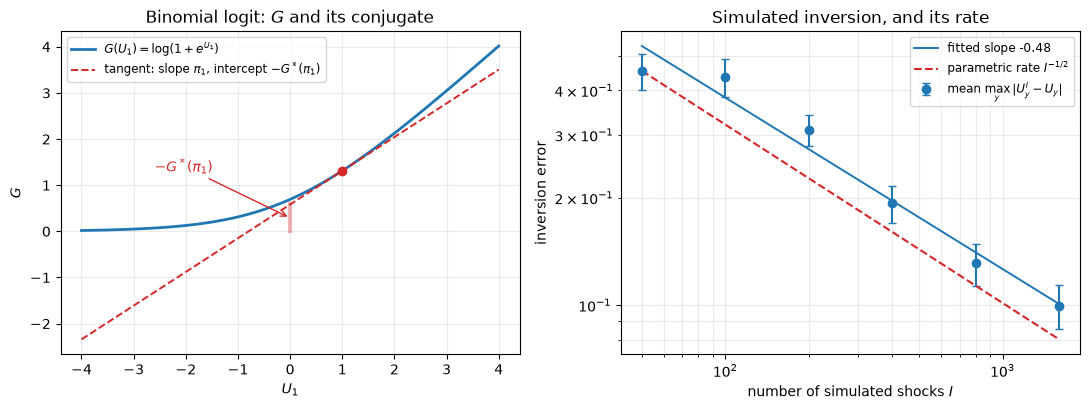

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# --- left: G and its tangent, binomial logit
U1 = np.linspace(-4, 4, 400)
Gvals = np.log1p(np.exp(U1))
U1s = 1.0
pi1s = 1 / (1 + np.exp(-U1s))
Gs = np.log1p(np.exp(U1s))
Gstar_s = pi1s * np.log(pi1s) + (1 - pi1s) * np.log(1 - pi1s)

ax[0].plot(U1, Gvals, lw=2, color='C0', label=r'$G(U_1)=\log(1+e^{U_1})$')
ax[0].plot(U1, pi1s * U1 - Gstar_s, lw=1.4, ls='--', color='C3',
           label=r'tangent: slope $\pi_1$, intercept $-G^*(\pi_1)$')
ax[0].plot([U1s], [Gs], 'o', color='C3', ms=6)
ax[0].plot([0, 0], [0, -Gstar_s], lw=3, color='C3', alpha=.35)
ax[0].annotate(r'$-G^*(\pi_1)$', xy=(0, -Gstar_s / 2), xytext=(-2.6, 1.3),
               arrowprops=dict(arrowstyle='->', color='C3'), color='C3')
ax[0].set_xlabel(r'$U_1$'); ax[0].set_ylabel(r'$G$')
ax[0].set_title('Binomial logit: $G$ and its conjugate')
ax[0].legend(loc='upper left', fontsize=8.5); ax[0].grid(alpha=.25)

# --- right: convergence of the LP inversion, with the measured rate
Ig = np.array(I_grid, float); eg = np.array(errs)
ax[1].errorbar(Ig, eg, yerr=np.array(sds) / np.sqrt(nrep), fmt='o', color='C0',
               capsize=3, label=r'mean $\max_y|U^I_y-U_y|$')
ax[1].plot(Ig, np.exp(intercept) * Ig ** slope, '-', color='C0', lw=1.4,
           label=f'fitted slope {slope:+.2f}')
ax[1].plot(Ig, eg[0] * np.sqrt(Ig[0] / Ig), '--', color='C3',
           label=r'parametric rate $I^{-1/2}$')
ax[1].set_xscale('log'); ax[1].set_yscale('log')
ax[1].set_xlabel('number of simulated shocks $I$'); ax[1].set_ylabel('inversion error')
ax[1].set_title('Simulated inversion, and its rate')
ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25, which='both')

plt.tight_layout(); plt.show()

*Left.* Everything in section 3 is in this picture. The share $\pi_1$ is a slope; the entropy of choice is (minus) an intercept; demand inversion is the question "which point of the curve has this slope?", and it has a unique answer exactly when $G$ is strictly convex — which is what full support buys.

*Right.* The simulated inversion converges — $\hat G^\ast \to G^\ast$ because $\mathcal{P}_I \to \mathcal{P}$ — and the fitted slope sits on top of the $I^{-1/2}$ reference. The error bars are the standard error of the mean over 16 seeds; they are what a four-replication version of this experiment would have been reading as signal.

## Summing up

* **One convex function, read two ways.** $G$ is the welfare of a population facing systematic utilities $U$; $G^\ast$ is the heterogeneity needed to rationalize shares $\pi$. Its gradient predicts demand; its conjugate's gradient inverts it. Chapter 2 will make both explicit for the logit and its generalizations; chapter 3 will estimate $U$ inside them; chapters 6 and 7 will change what $U$ means without changing this structure.
* **Demand inversion is a matching market.** The empirical inversion is an optimal transport problem between consumers' shocks and the alternatives, and the systematic utilities are its equilibrium prices. Complementary slackness says a consumer takes an option only when it is their argmax. The same LP, with a two-sided surplus in place of $\varepsilon_{iy}$, is the empirical matching model of the companion series.
* **Estimation is inversion.** The MLE of $U$ from observed choices is $\pi^{-1}(\hat\pi)$ — no likelihood needs to be written down. Its asymptotic variance is the sandwich $D^2G^\ast V_\pi D^2G^\ast$, which collapses to $V_\pi^{-1}$ in the logit; simulated coverage of the resulting intervals came within one point of nominal.
* **The economics: heterogeneity is the whole story, and it is an assumption.** Inverting the travel-mode shares under Gumbel and under Gaussian shocks gives the same *ranking* of modes but visibly different *magnitudes*. Shares identify utilities only up to the assumed distribution of tastes — which is why the rest of the book is, in a sense, a study of what one is allowed to assume about $\mathcal{P}$ and how to compute with it.

## Exercises

Exercises 1–3 are book exercises 1.1, 1.3 and 1.9 for chapter 1; solutions to the book versions exist in the author's solution set.

**1. (Proof — positivity of shares.)** Show that if $\mathcal{P}$ satisfies the continuity assumption 1.1 and the full support assumption 1.2, then $\pi_y(U)>0$ for every $y\in[Y]$ and every $U\in\mathbb{R}^Y$. Where exactly does full support enter? Give a distribution satisfying continuity but not full support for which some $\pi_y(U)=0$, and check numerically with `welfare_and_shares` that the accept–reject simulator returns an empty cell for it.

**2. (Proof — sign of the entropy of choice.)** Take no default option, and suppose $\mathbb{E}_{\mathcal{P}}[\varepsilon_y]=0$ for all $y\in[Y]$. Show that $G^\ast(\pi)\le 0$ for every $\pi$ in the simplex. *Hint: use $G^\ast(\pi) = -\mathbb{E}[\varepsilon_{y^\star}]$ and the fact that $y^\star$ selects the largest shock.* Interpret the inequality: why must "the heterogeneity needed to rationalize $\pi$" be nonnegative?

**3. (Computation — assessing simulation accuracy.)** Let $Y=3$ with no default option and $\mathcal{P}=\mathcal{N}(0,\mathbf{I}_3)$. (i) Simulate $\pi(U)$ at $U=(0.1,0,0.2)$ and report the variance–covariance matrix of your estimate; (ii) simulate $\pi^{-1}(\pi)$ at $\pi=(0.2,0.5,0.3)$, normalizing $U_1=0$, using `inversion_lp`, and report the variance–covariance matrix of *that* estimate over independent draws. Compare the two: which is the noisier operation at the same simulation budget, and does the asymptotic theory of section 5 explain the gap?

**4. (Computation — a failed assumption, computed.)** Take $Y=2$, no default option, and $\varepsilon_1=\varepsilon_2$ with the common value $\mathcal{N}(0,1)$. Does $\mathcal{P}$ satisfy assumption 1.1? Assumption 1.2? Now run `inversion_lp` on a target $\pi=(0.3,0.7)$ with shocks drawn from this distribution, for several values of $I$ and several seeds. Does $U^I$ settle down? Explain what you observe in terms of theorem 1.2 (at most one solution requires full support), and identify the flat stretch of the c.d.f. that is responsible.

**5. (Economics — inverse isotonicity, and where it is used.)** (i) Prove directly in the logit model that $\pi(U)\le\pi(U')$ implies $U\le U'$. *Hint: write $D=\sum_z e^{U_z}$, sum the share inequalities over $y\in[Y]$ to get $D\le D'$, then substitute back.* (ii) Explain in words why this is the property that makes Berry's inversion of market shares well posed, and why an econometrician should be uneasy about a demand system that violates it. (iii) Lecture 11 studies choice under capacity constraints, where $G$ is maximized subject to $\pi_y\le\bar\pi_y$. Conjecture what happens to inverse isotonicity when the constraint binds, and what the multiplier on it should be called.

---

### Run notes

`FAST_MODE = True` is the classroom setting: $10^5$ Monte Carlo draws, 8,000 coverage replications, and 16 replications on a convergence grid capped at $I=1600$. Setting it to `False` raises these to $2\times10^5$ draws, 20,000 replications, and 24 replications up to $I=3200$. Every assertion holds in both modes, and the quoted figures are stable across them to the precision at which they are quoted. The notebook is self-contained — numpy, scipy, pandas and matplotlib only, no Gurobi and no `mec` package — and downloads its single dataset from `math-econ-code/mec_datasets`.

**Next:** lecture 2 puts the Gumbel distribution behind $\varepsilon$ and asks what makes it special, generalizes to the multivariate extreme value class and the nested logit, and closes with the three max-stable families.